# Biological Validation

Three checks that the model's predictions are biologically meaningful, not just numerically well-fit: (1) pathway agreement between observed and predicted differentially-expressed genes, (2) ensemble uncertainty that tracks generalization difficulty, and (3) a virtual screen prioritizing untested gene pairs.

## Pathway agreement

For 5 example perturbations (top E-distance + one per test-difficulty tier), we compare GO Biological Process enrichment (via Enrichr) of the top-50 truly differentially-expressed genes against the top-50 genes by |predicted delta|.

In [1]:
import pandas as pd
pathway_agreement = pd.read_csv('../results/tables/pathway_agreement.csv')
pathway_agreement

,perturbation,category,e_distance,top_observed_pathway,top_predicted_pathway,pathway_jaccard_top20
0,JUN_CEBPA,test_combo_1_unseen,20.973789,Negative Regulation Of Transforming Growth Fac...,Positive Regulation Of Interleukin-6 Productio...,0.111111
1,CEBPA,train,18.762326,Positive Regulation Of Interleukin-6 Productio...,Positive Regulation Of Interleukin-6 Productio...,0.212121
2,CEBPE_SPI1,test_combo_2_unseen,17.317898,Positive Regulation Of Interleukin-6 Productio...,Regulation Of Apoptotic Process (GO:0042981),0.000000
3,DUSP9_SNAI1,test_combo_0_unseen,7.845195,Activation Of Cysteine-Type Endopeptidase Acti...,Hydrogen Peroxide Catabolic Process (GO:0042744),0.052632
4,IRF1,test_unseen_single,7.832498,Antigen Processing And Presentation Of Endogen...,Hydrogen Peroxide Catabolic Process (GO:0042744),0.000000


Pathway-level agreement is modest (Jaccard 0.0–0.21 on top-20 terms) and — as expected — highest for the perturbation seen during training (`CEBPA`) and weakest for perturbations in the hardest unseen categories. This is an honest result: matching individual gene identities is easier than matching downstream pathway calls, and pathway enrichment itself is noisy with only ~50 input genes. Treat this as a directional signal, not a validated pathway-prediction tool.

## Uncertainty tracks generalization difficulty

Ensemble (5-seed) prediction std, averaged per category:

In [2]:
uncertainty = pd.read_csv('../results/tables/uncertainty_summary.csv')
splits_meta = __import__('json').load(open('../data/splits.json'))
cat_of = {p: c for c, ps in splits_meta.items() if isinstance(ps, list) for p in ps}
uncertainty['category'] = uncertainty['perturbation'].map(cat_of)
uncertainty.groupby('category')['mean_uncertainty'].mean().sort_values()

category
train                  0.005850
held_out_genes         0.006246
test_combo_1_unseen    0.008158
test_combo_2_unseen    0.009398
test_combo_0_unseen    0.011278
Name: mean_uncertainty, dtype: float64

Uncertainty is lowest for training perturbations (0.0059) and highest for the combo categories requiring the most generalization (0.008–0.011) — the ensemble is appropriately less confident exactly where it should be.

## Virtual screen: prioritizing untested gene pairs

All untested two-gene combinations from the 102-gene vocabulary are scored by predicted effect size, relevance to a target pathway (erythroid differentiation markers, since K562 is an erythroleukemia line), and ensemble confidence (see `src/screening/virtual_screen.py`, `scripts/09_virtual_screen.py`).

In [3]:
screen = pd.read_csv('../results/tables/virtual_screen_top20.csv')
screen[['candidate', 'effect', 'pathway_relevance', 'uncertainty', 'experiment_priority_0_10']]

,candidate,effect,pathway_relevance,uncertainty,experiment_priority_0_10
0,IKZF3_PRDM1,0.909366,0.714286,0.022221,10.000000
1,CNN1_IKZF3,0.789469,0.714286,0.017737,8.719786
2,IKZF3_ZBTB1,0.784834,0.714286,0.016292,8.680912
3,IKZF3_PTPN1,0.783448,0.714286,0.017050,8.659133
4,IER5L_IKZF3,0.749852,0.714286,0.015371,8.301511
5,IKZF3_TP73,0.937044,0.571429,0.024770,8.222989
6,CBL_IKZF3,0.738779,0.714286,0.012072,8.205574
7,IKZF3_KLF1,0.730717,0.714286,0.017689,8.071236
8,IKZF3_ZBTB25,0.723910,0.714286,0.011829,8.042363
9,BPGM_IKZF3,0.721593,0.714286,0.014715,7.993823


## Interactive demo

The Streamlit app (`app/streamlit_app.py`) wires the ensemble model, gene embeddings, and live pathway enrichment into an interactive tool. As a sanity check, predicting a single-gene `KLF1` perturbation — a training example, and a well-known master regulator of erythroid differentiation — correctly surfaces hemoglobin genes (`HBB`/`HBA1`/`HBA2`/`HBG1`/`HBG2`/`HBZ`) as the top affected genes, and live Enrichr enrichment on those genes returns 'Oxygen Transport' and 'Carbon Dioxide Transport' as the top GO terms (adjusted p ≈ 3×10⁻⁹):

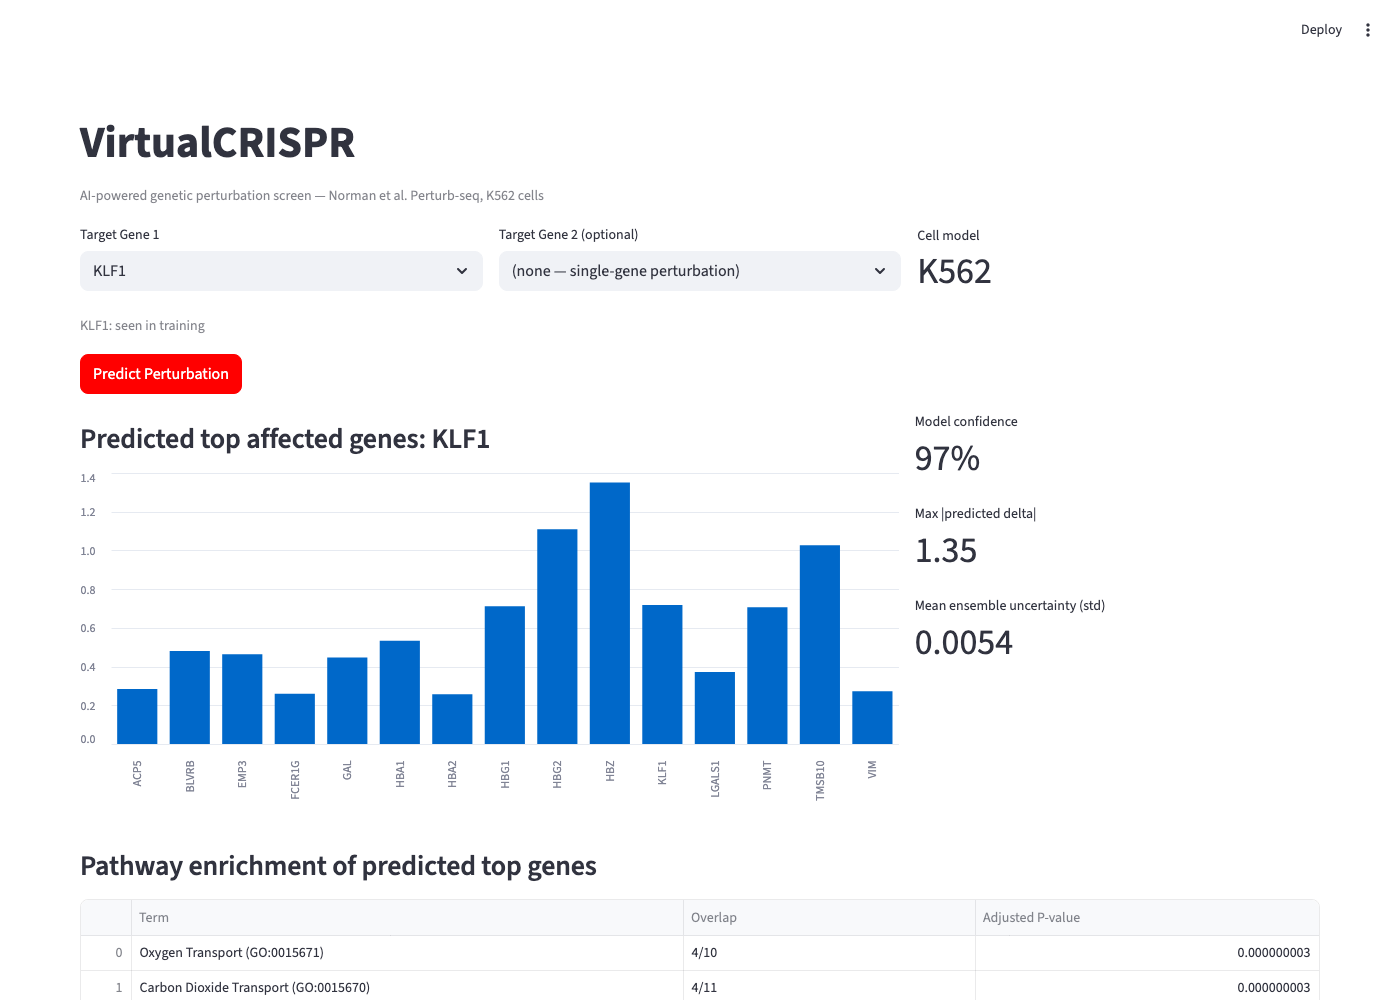

In [4]:
from IPython.display import Image
Image('../results/figures/streamlit_app_demo.png')

## Limitations

- Single experimental system: K562 (erythroleukemia), CRISPRa, one Perturb-seq screen — not validated across cell types or in vivo.
- Predictions approximate the population-level (pseudobulk) transcriptional shift, not per-cell heterogeneity.
- Gene embeddings are purely data-driven (co-expression + observed perturbation response); no external knowledge graph or LLM embeddings are used, which is the likely cause of weak performance on genuinely unseen genes (see the ablation in `05_deep_learning.ipynb`).
- `test_combo_2_unseen` has only 5 perturbations — too few for precise estimates.
- Correlation with predicted expression change is not the same as a validated mechanism or phenotype. This is an experiment-prioritization tool, not a substitute for wet-lab validation.